# <span style="color: #57A0D2"> Spotify Top 100</span> <span style="color: #4D516D">Linear Regression </span>

In [16]:
# import top2019csv data into jupyter notebook
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
df = pd.read_csv("top2019.csv")

### <span style="color: #4D516D">1. What is Machine Learning</span>
- Machine learning is a method of using data to train a model so it can recognize patterns and make predictions or decisions without being explicitly programmed for every case.
- The goal of machine learning is to build a model that can learn relationships within data and use those patterns to make accurate predictions on new, unseen data.
- We could most likely make a prediction on valence or danceability as those heavily depend on tempo, energy, loudness, instrumentalness, etc.

### <span style="color: #4D516D">2. Preliminary Analysis</span>

In [7]:
df.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
count,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.0
mean,0.719400,0.60462,5.280000,-6.229000,0.580000,0.127582,0.299381,0.006039,0.132792,0.490460,120.425700,201691.620000,4.0
std,0.130358,0.16975,3.295266,2.725249,0.498569,0.103008,0.255321,0.029065,0.074088,0.219144,28.740856,44213.177325,0.0
min,0.351000,0.11100,0.000000,-14.505000,0.000000,0.029000,0.005130,0.000000,0.057400,0.120000,71.105000,113000.000000,4.0
25%,0.657500,0.52000,2.000000,-7.056000,0.000000,0.053675,0.095900,0.000000,0.088425,0.330500,97.316000,175840.000000,4.0
50%,0.743000,0.62400,5.000000,-5.759000,1.000000,0.081350,0.244000,0.000000,0.106000,0.495000,116.125500,193657.500000,4.0
75%,0.814500,0.73225,8.000000,-4.295250,1.000000,0.199000,0.449250,0.000003,0.141250,0.637000,137.478750,215372.250000,4.0
max,0.907000,0.90400,11.000000,-2.652000,1.000000,0.375000,0.978000,0.162000,0.437000,0.952000,179.974000,354320.000000,4.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50 non-null     object 
 1   name              50 non-null     object 
 2   artists           50 non-null     object 
 3   danceability      50 non-null     float64
 4   energy            50 non-null     float64
 5   key               50 non-null     float64
 6   loudness          50 non-null     float64
 7   mode              50 non-null     float64
 8   speechiness       50 non-null     float64
 9   acousticness      50 non-null     float64
 10  instrumentalness  50 non-null     float64
 11  liveness          50 non-null     float64
 12  valence           50 non-null     float64
 13  tempo             50 non-null     float64
 14  duration_ms       50 non-null     float64
 15  time_signature    50 non-null     float64
dtypes: float64(13), object(3)
memory usage: 6.4+ K

### <span style="color: #4D516D">3. Test Split</span>

In [10]:
X = df[['energy', 'loudness', 'tempo', 'valence']]
y = df['danceability']
# Note I labeled these X_train1, X_test1, y_train1, y_test1 as W4 has 3 different models so the number corresponds to the model number
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train1.shape, X_test1.shape)
print(y_train1.shape, y_test1.shape)

(40, 4) (10, 4)
(40,) (10,)


### <span style="color: #4D516D">4. Linear Regression</span>

In [6]:
model1 = LinearRegression()
model1.fit(X_train1, y_train1)

print("Coefficients:", model1.coef_)
print("Intercept:", model1.intercept_)

Coefficients: [0.12096796 0.00424671 0.0006663  0.22904289]
Intercept: 0.4745069856224865


### <span style="color: #4D516D">5. Scatterplot</span>
If the model were accurate the points would lie close to a diagonal line, indicating that the predicted values closely match the actual values. This scatterplot hints at an upwards trend, but the points are not close to a diagonal line, indicating that the predictions are not very accurate and there is significant error.

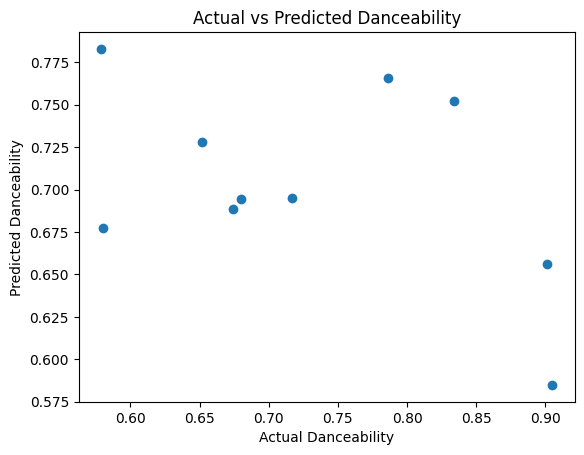

In [7]:
# Note y_pred1 to represent prediction for the first model
y_pred1 = model1.predict(X_test1)
plt.scatter(y_test1, y_pred1)

plt.xlabel("Actual Danceability")
plt.ylabel("Predicted Danceability")
plt.title("Actual vs Predicted Danceability")
plt.show()

### <span style="color: #4D516D">6. Smaller training set</span>
This model appears more scattered and less structured than the first. Because it was trained on less data, it captures less of the underlying pattern and tends to predict values closer to the average rather than accurately trying to model variation. Visually, the data is clumped around the center/right side of the plot, showing no clear upwards trend and that having less training data typically reduces model accuracy.

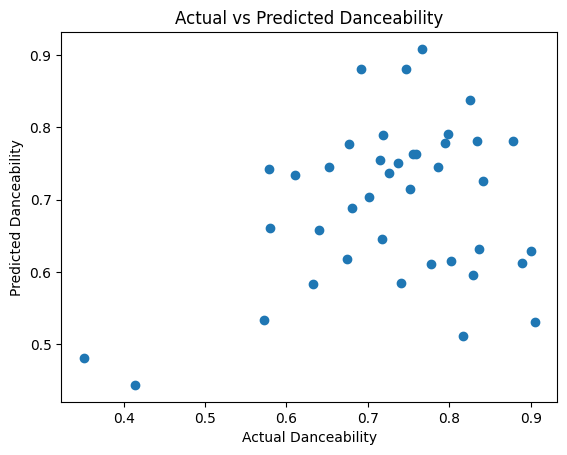

In [9]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.8, random_state=42)
model2 = LinearRegression()
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)
plt.scatter(y_test2, y_pred2)

plt.xlabel("Actual Danceability")
plt.ylabel("Predicted Danceability")
plt.title("Actual vs Predicted Danceability")
plt.show()

### <span style="color: #4D516D">7. All features in X</span>
If we ignore the one extreme outlier in the scatterplot that is significantly skewing our R^2 value, it doe appear to have a slightly clearer upwards trend than the previous models. Using more features can improve the model because it has more information, but that could also introduce more noise as we can see here. The performance of this model is highly dependent on whether the added features are actually useful for predicting danceability.

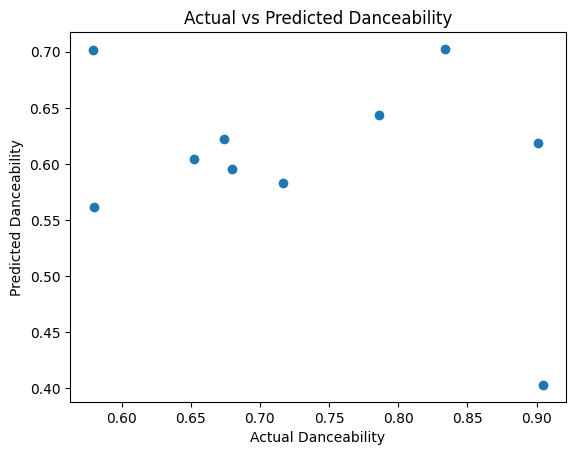

R^2: -2.1629623585597666


In [14]:
# Use all numeric columns except the target
X = df[['energy', 'key', 'loudness', 'mode', 'speechiness',
         'acousticness', 'instrumentalness', 'liveness',
         'valence', 'tempo', 'duration_ms', 'time_signature']]
y = df['danceability']
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y, test_size=0.2, random_state=42)

model3 = LinearRegression()
model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)
plt.scatter(y_test3, y_pred3)

plt.xlabel("Actual Danceability")
plt.ylabel("Predicted Danceability")
plt.title("Actual vs Predicted Danceability")
plt.show()
print("R^2:", r2_score(y_test3, y_pred3))

### <span style="color: #4D516D">8. Feature Correlation</span>
The correlation heatmap shows that valence has the strongest positive relationship with danceability, followed by energy. This suggests that songs that are more positive and energetic tend to be more danceable. Most other features have weak correlations, indicating they contribute less to predicting danceability and may add limited value or introduce noise.

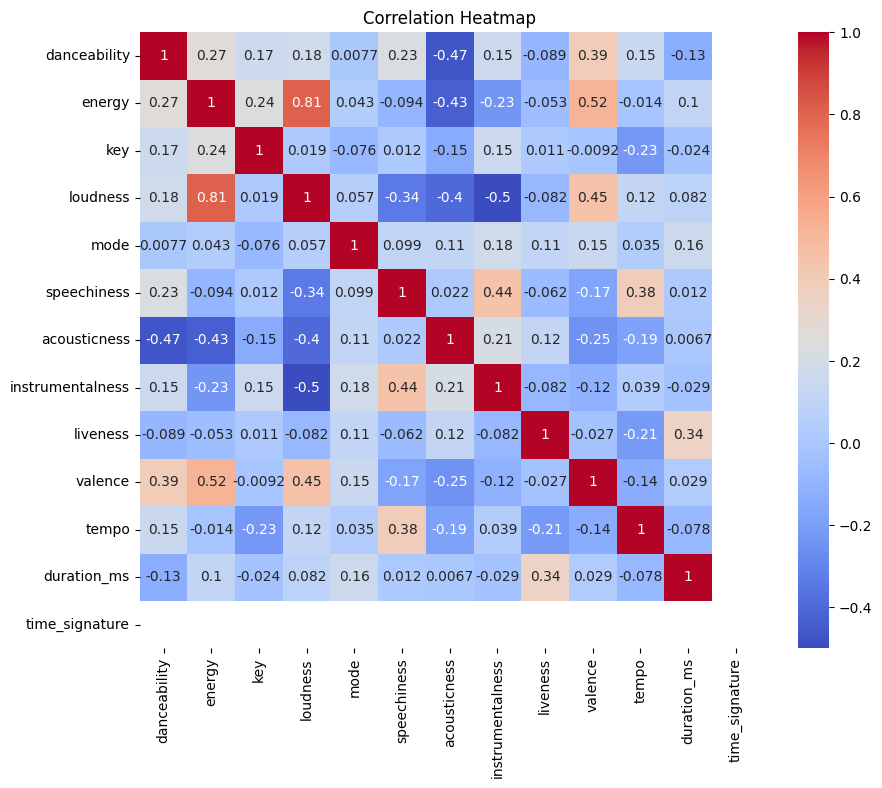

In [15]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### <span style="color: #4D516D">First attempt at Normalizing Data (Not part of the worksheet)</span>

R^2: -0.7068019030733639
MSE: 0.02235937801856556


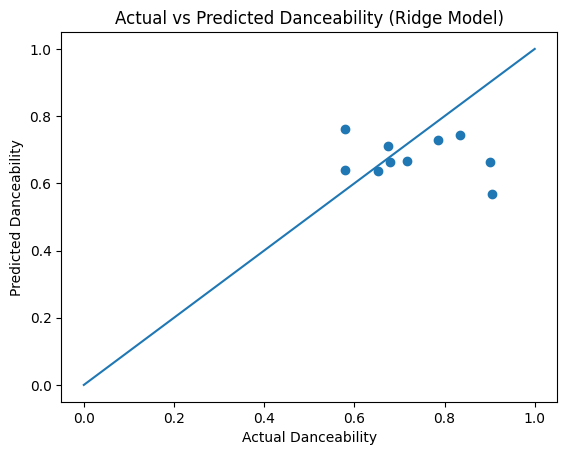

In [44]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("top2019.csv")

# Features: all useful numeric ones except target
X = df[['energy', 'key', 'loudness', 'mode', 'speechiness',
        'acousticness', 'instrumentalness', 'liveness',
        'valence', 'tempo', 'duration_ms']]

# Target
y = df['danceability']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale data
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Better model: Ridge regression
best_model = Ridge(alpha=1.0)
best_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = best_model.predict(X_test_scaled)

# Accuracy
print("R^2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

# Plot
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Danceability")
plt.ylabel("Predicted Danceability")
plt.title("Actual vs Predicted Danceability (Ridge Model)")
plt.plot([0, 1], [0, 1])
plt.show()

### <span style="color: #4D516D">9. Reflect</span>
The variables in the dataset are measured on different scales (such as valence, energy, and loudness), so normalization can help ensure that no single feature dominates the model. Ideally, our model would perform well on new, unseen data, not just the training data, so it should have strong predictive power while avoiding overfitting. To improve this model, I would try feature selection to remove any irrelevant variables that may cause extra noise in our results.

### <span style="color: #4D516D">10. R^2 and MSE comparison table</span>
- R² measures how much of the variation in the target variable, danceability, is explained by the model (yay stats!). A value closer to 1 means the model explains the data well, while a value near 0 means it does not explain much. A negative R² means the model performs worse than simply predicting the average danceability for every song.
MSE stands for Mean Squared Error, measuring the average squared difference between the predicted and actual values, so the lower the MSE is the better.
- From my results Model 2 is the best of the three, because it has the highest R² (least negative) and the lowest MSE. However, all three models performed poorly overall, since every R² value is negative.

In [17]:
r2_1 = r2_score(y_test1, y_pred1)
mse_1 = mean_squared_error(y_test1, y_pred1)

r2_2 = r2_score(y_test2, y_pred2)
mse_2 = mean_squared_error(y_test2, y_pred2)

r2_3 = r2_score(y_test3, y_pred3)
mse_3 = mean_squared_error(y_test3, y_pred3)

results = pd.DataFrame({'Model': ['Model 1', 'Model 2', 'Model 3'],'R^2': [r2_1, r2_2, r2_3],'MSE': [mse_1, mse_2, mse_3]})
results

,Model,R^2,MSE
0,Model 1,-0.734258,0.022719
1,Model 2,-0.397104,0.019376
2,Model 3,-2.162962,0.041435
